In [ ]:
# conda activate genomic_tools


library(fgsea)
library(dplyr)
library(UpSetR)
library(ggplot2)
library(msigdbr)
library(stringr)
library(data.table)

In [2]:
# For each cell type, run fgsea on the ranked list of genes from the eigengene corrlelation analysis

In [3]:
psi_corr_df <- fread("data/ctype_exons/exon_PSI_abundance_correlations.csv", data.table=FALSE)
psi_fdr_df <- fread("data/ctype_exons/exon_PSI_abundance_correlation_FDRs.csv", data.table=FALSE)

In [4]:
msigdbr_collections()

db_version,gs_collection,gs_subcollection,gs_collection_name,num_genesets
<chr>,<chr>,<chr>,<chr>,<int>
2026.1.Hs,C1,,Positional,302
2026.1.Hs,C2,CGP,Chemical and Genetic Perturbations,3555
2026.1.Hs,C2,CP,Canonical Pathways,19
2026.1.Hs,C2,CP:BIOCARTA,BioCarta Pathways,292
2026.1.Hs,C2,CP:KEGG_LEGACY,KEGG Legacy Pathways,186
2026.1.Hs,C2,CP:KEGG_MEDICUS,KEGG Medicus Pathways,658
2026.1.Hs,C2,CP:PID,PID Pathways,196
2026.1.Hs,C2,CP:REACTOME,Reactome Pathways,1839
2026.1.Hs,C2,CP:WIKIPATHWAYS,WikiPathways,925


In [5]:
gs_GO <- msigdbr(collection="C5") # , subcollection="GO:BP")
gs_GO_list <- tapply(gs_GO$gene_symbol, INDEX=gs_GO$gs_name, FUN=list)
gs_GO_list <- gs_GO_list[grep("^HP", names(gs_GO_list), invert=TRUE)]
gs_GO_list <- gs_GO_list[grep("^GOCC", names(gs_GO_list), invert=TRUE)]

length(gs_GO_list)

[1] 9410

In [6]:
min_set_size <- 5
max_set_size <- 200

set_sizes <- lengths(gs_GO_list)
mask <- (set_sizes < max_set_size) & (set_sizes > min_set_size)
gs_GO_list <- gs_GO_list[mask]

print(length(gs_GO_list))

[1] 7825


In [ ]:
ctypes <- colnames(psi_corr_df)[3:ncol(psi_corr_df)]
ctype_res <- vector(mode="list", length=length(ctypes))
names(ctype_res) <- ctypes

# Get enrichments for each cell type's regulated splicing events

for(ct in ctypes) {
    print(ct)

    # for each gene: select strongest effect size
    psi_corr_df_temp <- psi_corr_df %>%
        dplyr:::mutate(Cor=.data[[ct]], .before=Gene) %>%
        dplyr::group_by(Gene) %>%
        slice_max(Cor, with_ties=FALSE)

    set.seed(1)

    gene_ranks <- psi_corr_df_temp$Cor
    names(gene_ranks) <- psi_corr_df_temp$Gene
    gene_ranks <- sort(gene_ranks, decreasing=TRUE) # rank exons by abs(correlation with cell type)

    fgsea_res <- fgsea(pathways=gs_GO_list, stats=gene_ranks, scoreType="pos")
    fgsea_res <- fgsea_res %>%
        filter(padj < 0.05) %>%
        arrange(padj)

    cp <- collapsePathways(fgsea_res, gs_GO_list, gene_ranks)
    main_res <- fgsea_res[fgsea_res$pathway %in% cp$mainPathways] 
    main_res$ctype <- ct
    ctype_res[[ct]] <- main_res
}

[1] "CGE Class"


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.36% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.37% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.37% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.37% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(p

[1] "All GABAergic"


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(p

[1] "All Neuronal"


...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.4% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.4% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.4% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.4% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathw

[1] "Endo"


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.46% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


[1] "Peri"


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.53% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


In [75]:
ctype_res_all <- ctype_res

In [ ]:
ctype_res <- ctype_res_all[!names(ctype_res_all) %in% c('CGE Class', 'All GABAergic', 'Upper layer glutamatergic', 'Deep layer glutamatergic')]

In [95]:
for (i in 1:length(ctype_res)) { 
    ctype_res_df <- ctype_res[[i]] %>%
        slice_min(padj, n=10)

    if (dim(ctype_res_df)[1] == 0) {
        next
    }

    ctype <- names(ctype_res)[i] 
    options(repr.plot.width = 15, repr.plot.height = 10)

    ctype_res_df$pathway <- gsub("_", " ", ctype_res_df$pathway)

    print(
        ggplot(ctype_res_df, aes(
            x = NES,
                y = reorder(pathway, NES),
                size = size,
                color = padj
            )) +
        geom_point(alpha = 0.8) +
        scale_color_gradient(
            low = "#C1392B", high = "#BDC3C7",
            name = "padj", trans = "log10"
        ) +
        scale_size_continuous(name = "Gene set size", range = c(2, 10)) +
        scale_y_discrete(labels = function(x) tolower(stringr::str_wrap(x, width = 20))) +
        labs(title=ctype, x = "NES", y = NULL) +
        theme_bw(
            base_size = 16 
        )
    )
}


ERROR: Error in ctype_res[[i]]: subscript out of bounds


In [82]:
ctype_set_list <- lapply(ctype_res, function(res) res$pathway)

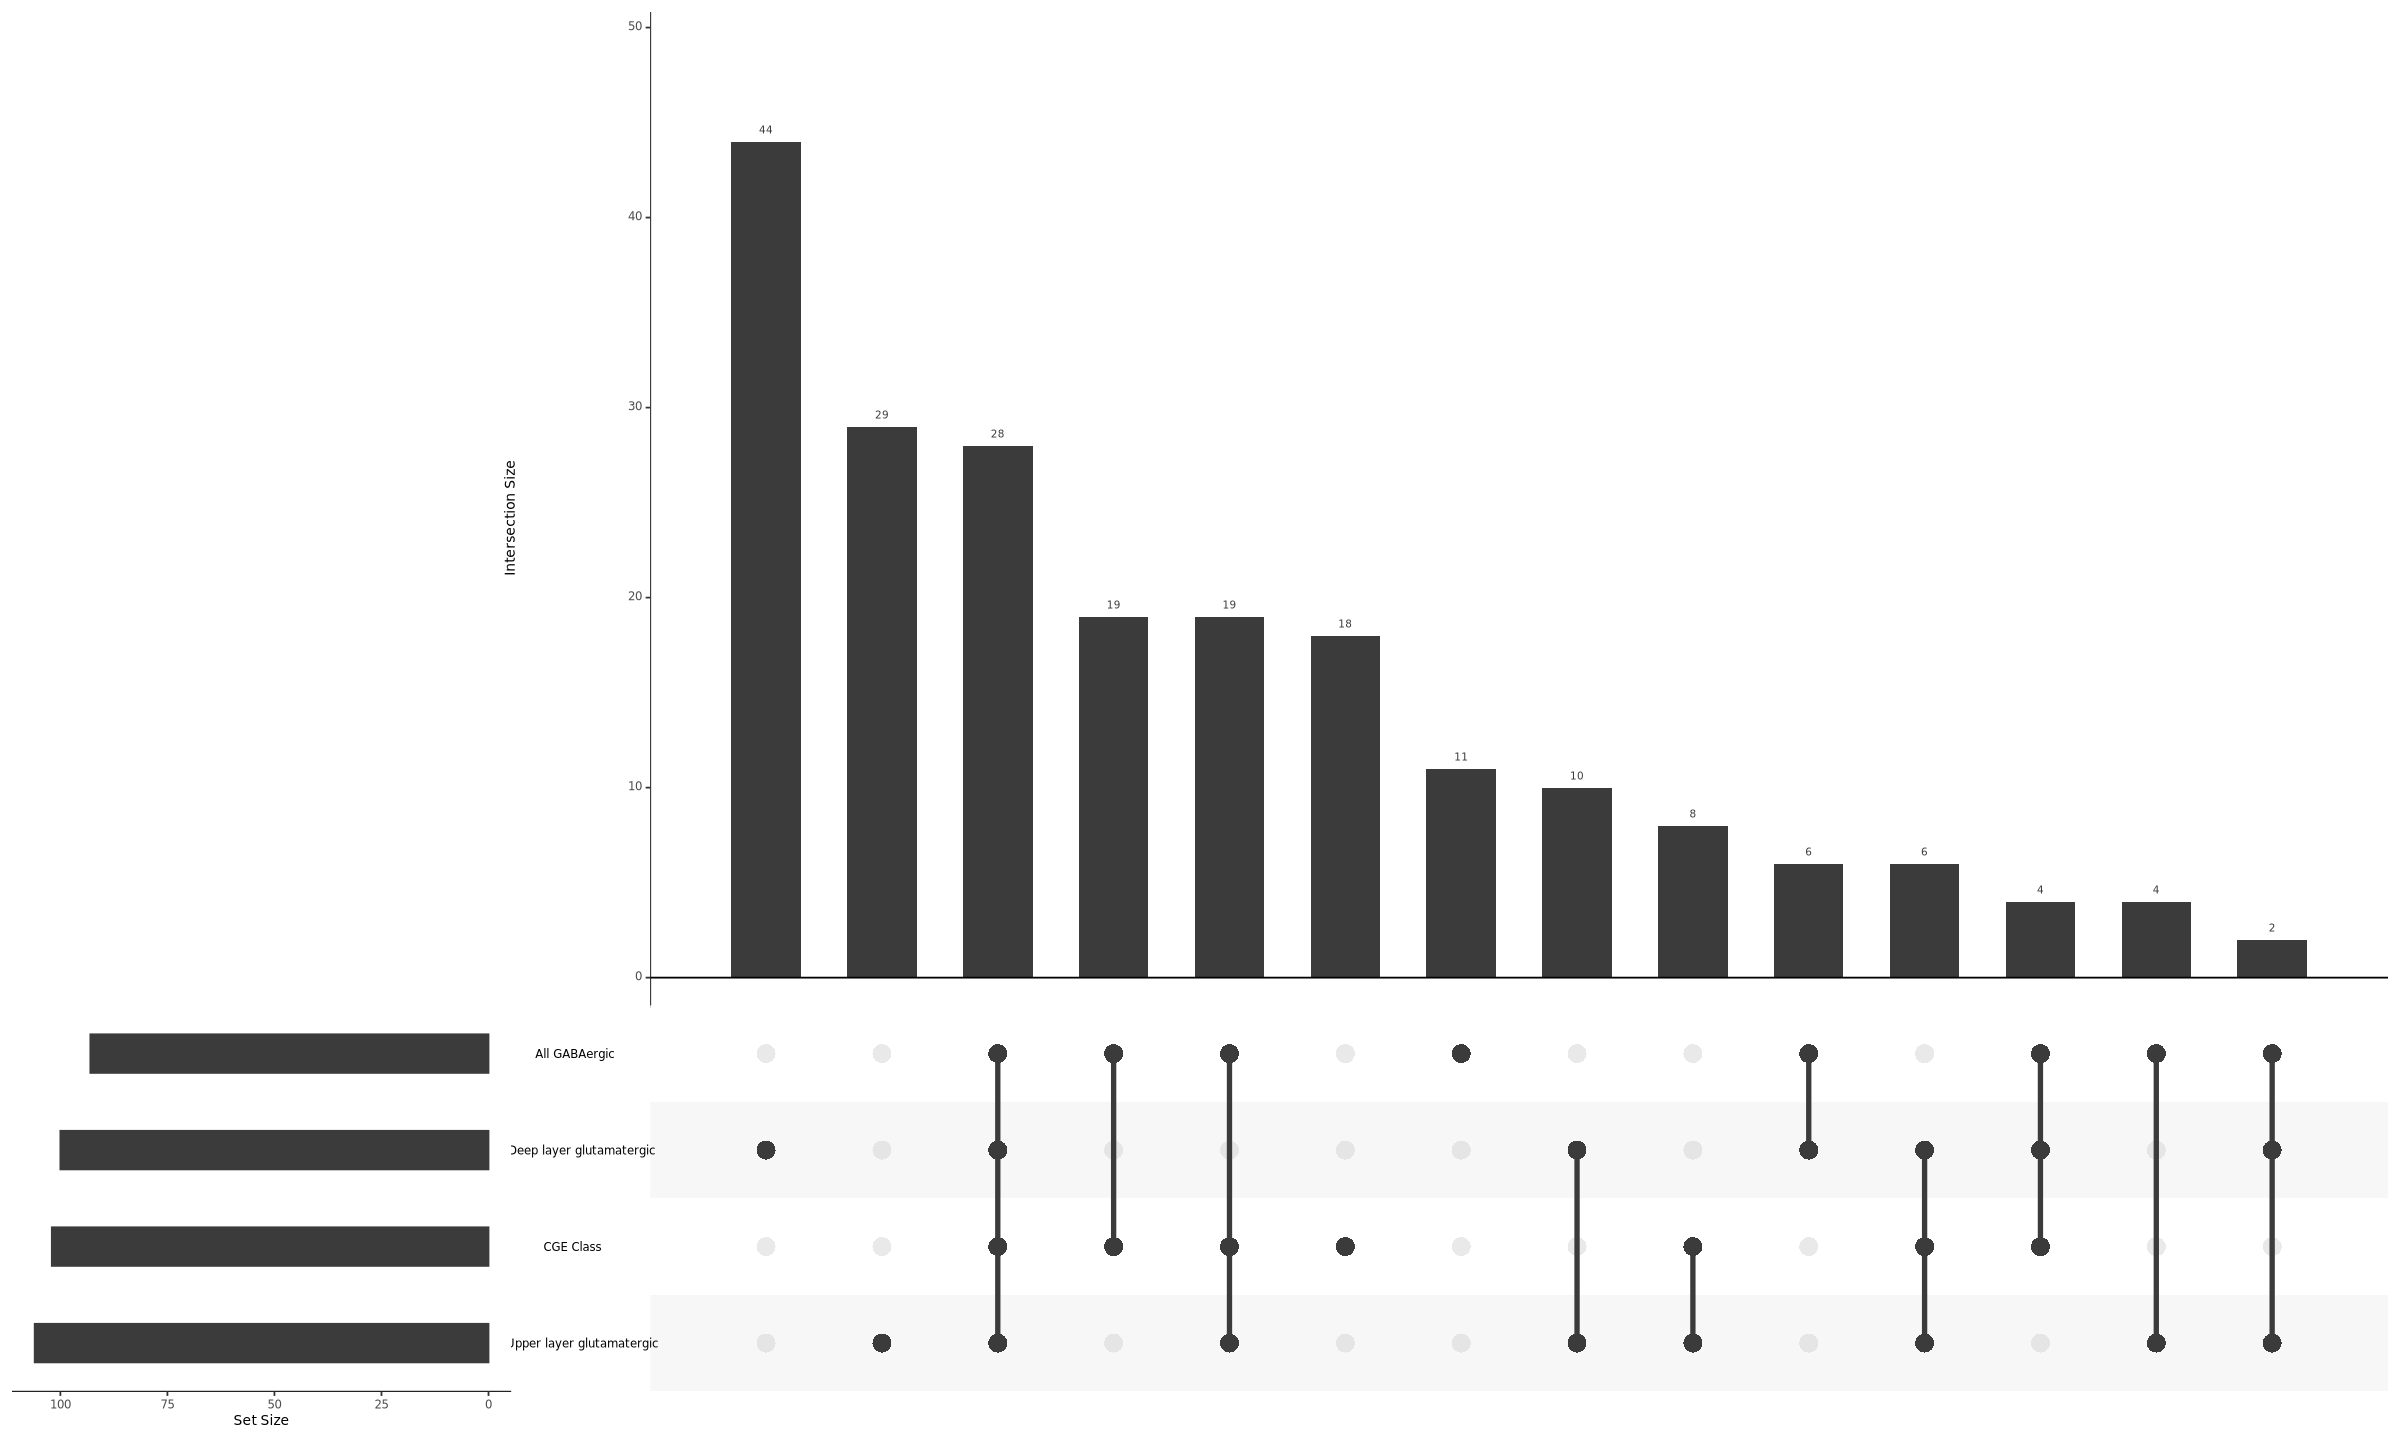

In [88]:
options(repr.plot.width = 20, repr.plot.height = 12)

upset(fromList(ctype_set_list), nsets = length(ctype_set_list), point.size = 5, line.size = 1.5, order.by = "freq")


In [93]:
i = 4
print(names(ctype_set_list)[i])
data.frame(
    setdiff(ctype_set_list[[i]], unlist(ctype_set_list[-i]))
)

[1] "Deep layer glutamatergic"


setdiff.ctype_set_list..i....unlist.ctype_set_list..i...
<chr>
GOBP_CELL_SUBSTRATE_JUNCTION_ORGANIZATION
GOBP_REGULATION_OF_CALCIUM_ION_TRANSMEMBRANE_TRANSPORT
GOBP_POSITIVE_REGULATION_OF_TRANSMEMBRANE_TRANSPORT
GOBP_REGULATION_OF_WOUND_HEALING_SPREADING_OF_EPIDERMAL_CELLS
GOMF_PHOSPHATIDYLINOSITOL_4_5_BISPHOSPHATE_BINDING
GOBP_REGULATION_OF_SKELETAL_MUSCLE_ADAPTATION
GOBP_CALCIUM_ION_IMPORT
GOBP_POSITIVE_REGULATION_OF_PLASMA_MEMBRANE_BOUNDED_CELL_PROJECTION_ASSEMBLY
GOBP_MODULATION_OF_EXCITATORY_POSTSYNAPTIC_POTENTIAL


In [68]:
unique_to_first

[1] "GOBP_REGULATION_OF_MICROTUBULE_CYTOSKELETON_ORGANIZATION"                              
 [2] "GOBP_POSITIVE_REGULATION_OF_SYNAPTIC_TRANSMISSION_GLUTAMATERGIC"                       
 [3] "GOMF_HIGH_VOLTAGE_GATED_CALCIUM_CHANNEL_ACTIVITY"                                      
 [4] "GOBP_NEGATIVE_REGULATION_OF_CHEMOKINE_MEDIATED_SIGNALING_PATHWAY"                      
 [5] "GOMF_VOLTAGE_GATED_CHANNEL_ACTIVITY"                                                   
 [6] "GOBP_POSITIVE_REGULATION_OF_CELL_MORPHOGENESIS"                                        
 [7] "GOBP_REGULATION_OF_NEURON_MIGRATION"                                                   
 [8] "GOBP_NEGATIVE_REGULATION_OF_AMYLOID_PRECURSOR_PROTEIN_CATABOLIC_PROCESS"               
 [9] "GOBP_ATRIAL_CARDIAC_MUSCLE_TISSUE_MORPHOGENESIS"                                       
[10] "GOMF_STRUCTURAL_CONSTITUENT_OF_POSTSYNAPTIC_SPECIALIZATION"                            
[11] "GOBP_ADULT_BEHAVIOR"                                                                   
[12] "GOBP_REGULATION_OF_MEMBRANE_DEPOLARIZATION_DURING_CARDIAC_MUSCLE_CELL_ACTION_POTENTIAL"
[13] "GOBP_MICTURITION"                                                                      
[14] "GOBP_NEGATIVE_REGULATION_OF_PROTEIN_LOCALIZATION_TO_NUCLEUS"                           
[15] "GOBP_FOREBRAIN_CELL_MIGRATION"                                                         
[16] "GOMF_GAMMA_CATENIN_BINDING"                                                            
[17] "GOBP_CELL_CELL_JUNCTION_ASSEMBLY"                                                      
[18] "GOBP_REGULATION_OF_PROTEIN_CONTAINING_COMPLEX_DISASSEMBLY"

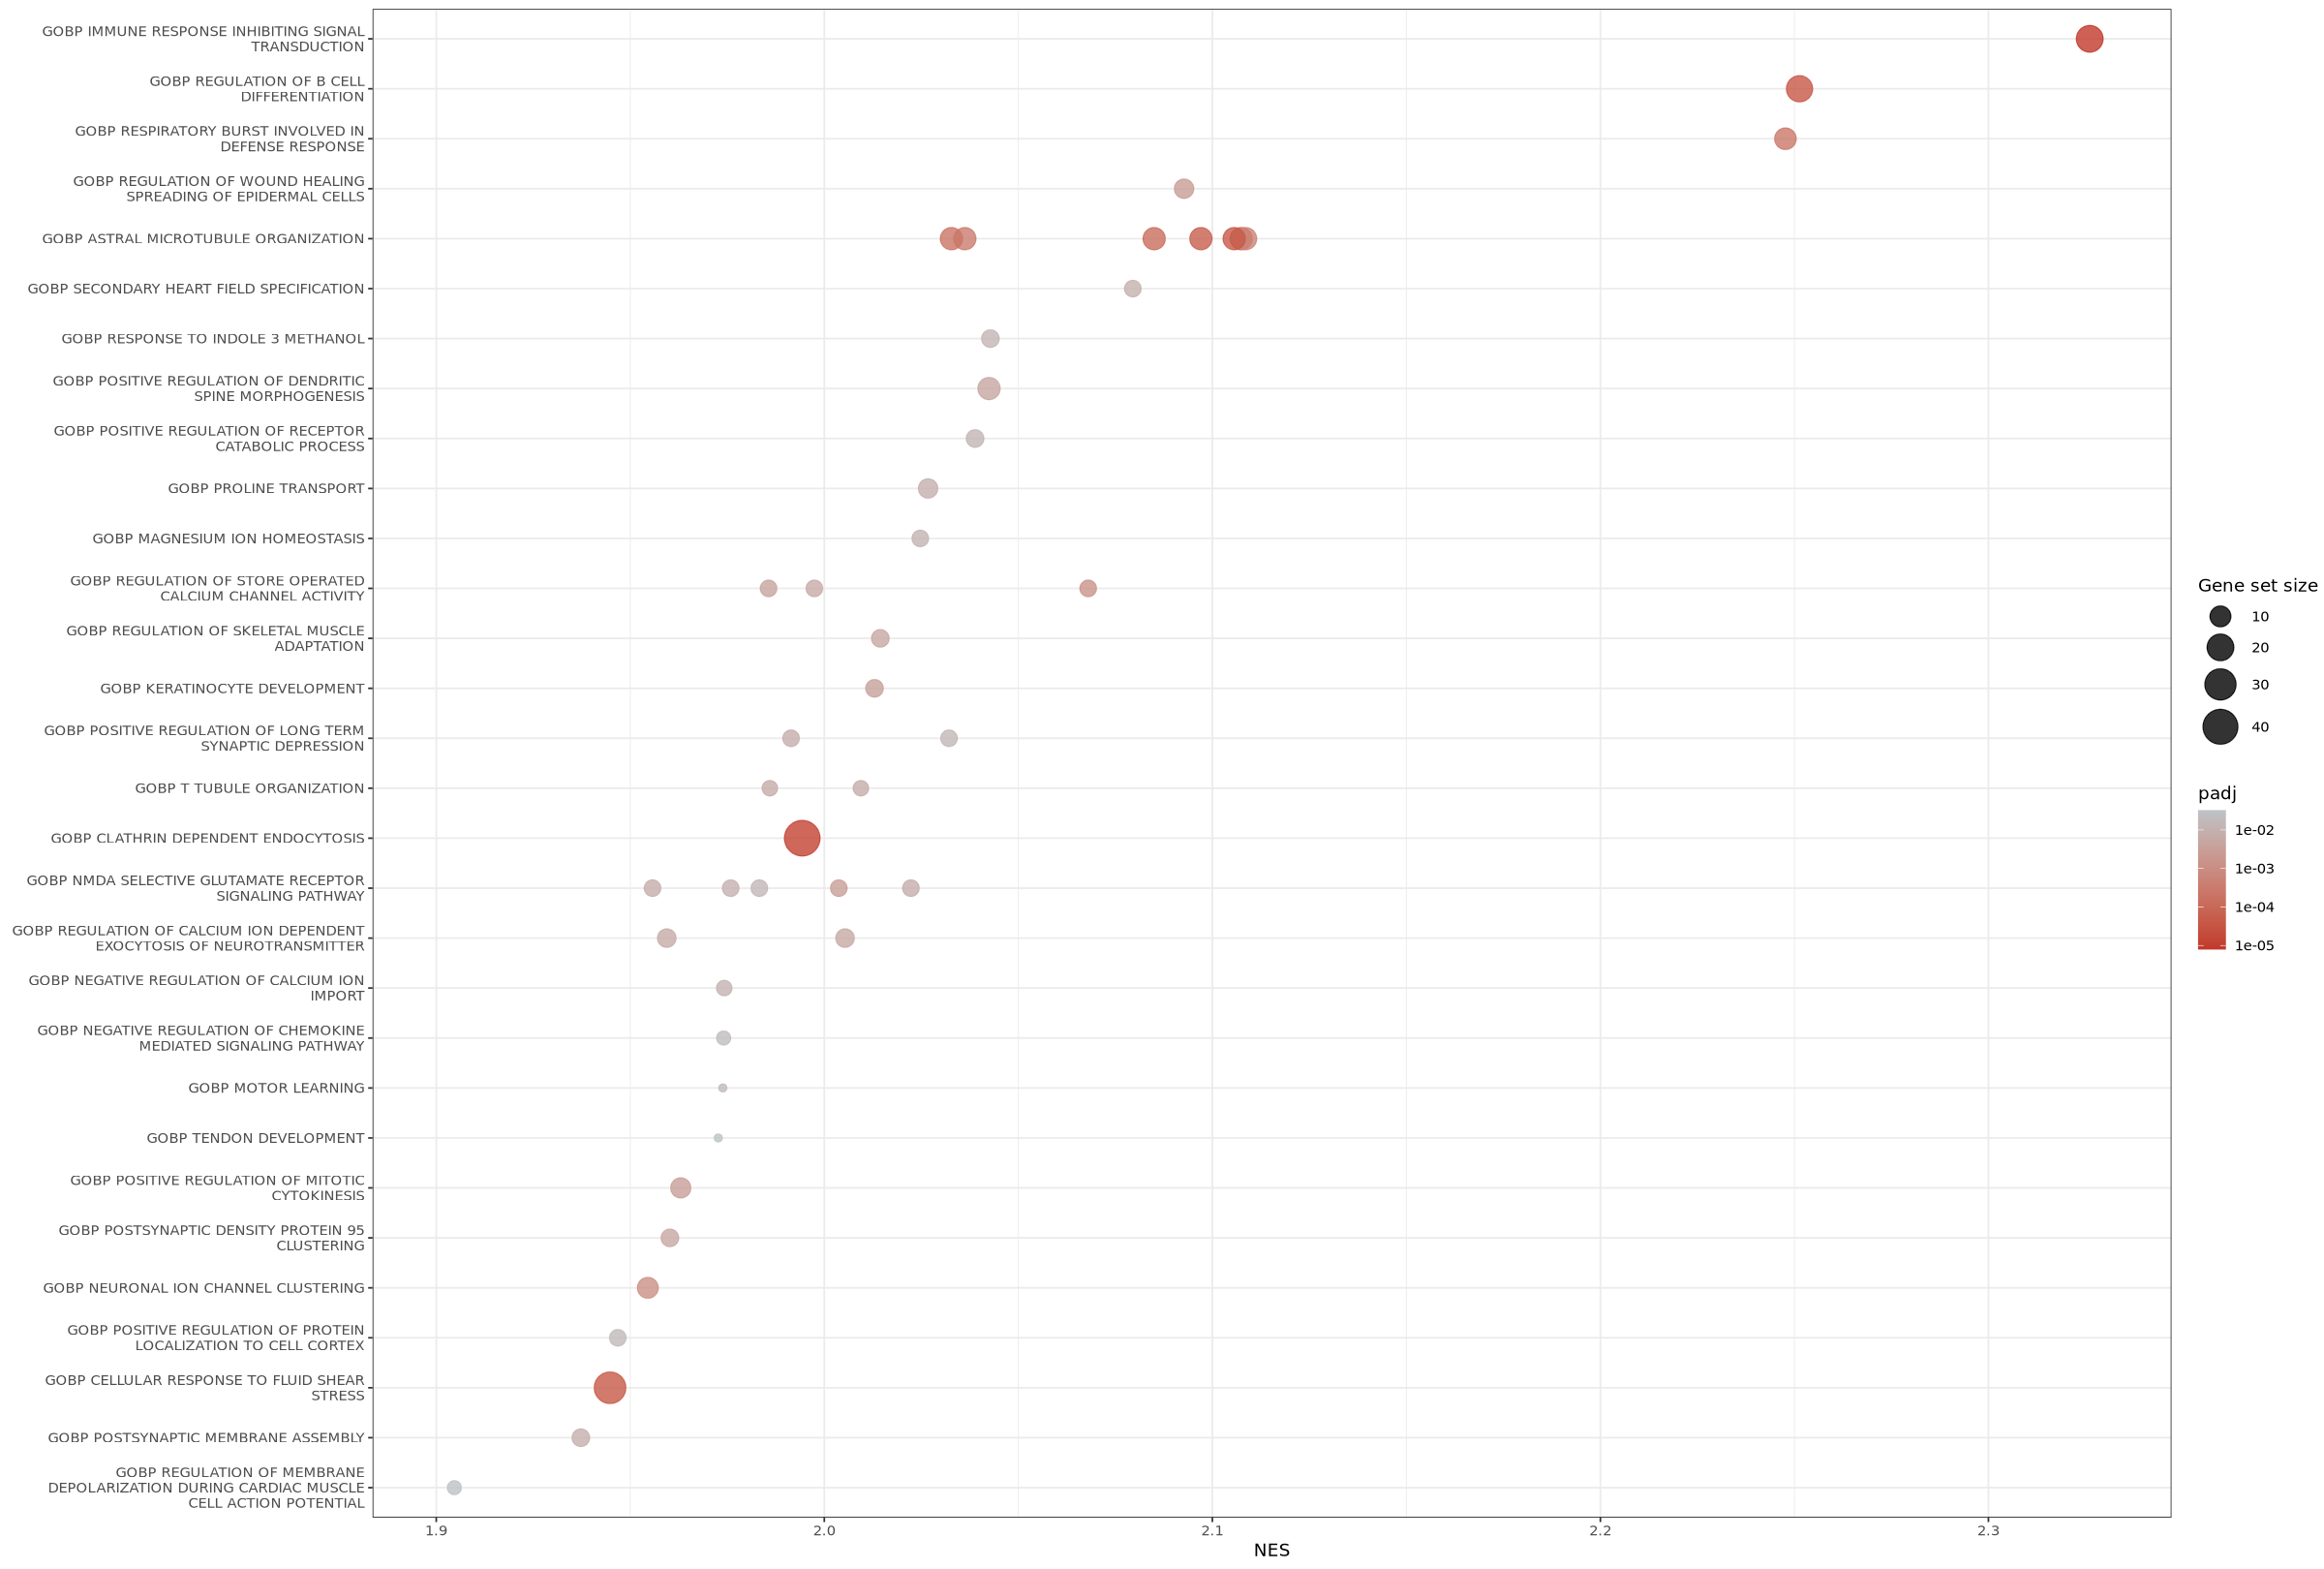

In [71]:
n_paths <- nrow(ctype_res_df)
options(repr.plot.width = 20, repr.plot.height = max(4, n_paths * 0.3))

ctype_res_df$pathway <- gsub("_", " ", ctype_res_df$pathway)

ggplot(ctype_res_df, aes(
        x = NES,
        y = reorder(pathway, NES),
        size = size,
        color = padj
    )) +
  geom_point(alpha = 0.8) +
  scale_color_gradient(
    low = "#C1392B", high = "#BDC3C7",
    name = "padj", trans = "log10"
  ) +
  scale_size_continuous(name = "Gene set size", range = c(2, 10)) +
  scale_y_discrete(labels = function(x) stringr::str_wrap(x, width = 40)) +
  labs(x = "NES", y = NULL) +
  theme_bw(base_size = 11)
